#Import Libraries

In [57]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shutil
import hashlib
import json

from PIL import Image

import torch
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder # Corrected import

from sklearn.model_selection import train_test_split

# Import kagglehub here, as it's used early for dataset download
import kagglehub

#Project Configuration

In [41]:
PROJECT_NAME = "Lifora AI"
IMAGE_SIZE = (224,224)
BATCH_SIZE = 32
RANDOM_SEED = 42 # Used for general random operations
SEED = 42 # Used for torch, numpy, and python random seed
NUM_WORKERS = 2 # For DataLoader
VALID_EXTENSIONS = (".jpg", ".jpeg", ".png")
OUTPUT_DATASET = "/content/processed_dataset"
EXPORT_DIR = "/content/exports" # Centralized export directory

## Set Random Seed


In [42]:
import random
import numpy as np
import torch

# Use RANDOM_SEED defined in project configuration
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

print("="*50)
print("Random Seed:", SEED)
print("Reproducibility Enabled")
print("="*50)

Random Seed: 42
Reproducibility Enabled


In [43]:
# Download dataset once and define base paths
path = kagglehub.dataset_download("nodoubttome/skin-cancer9-classesisic")
dataset_path = os.path.join(
    path,
    "Skin cancer ISIC The International Skin Imaging Collaboration"
)
train_path = os.path.join(dataset_path, "Train")

Using Colab cache for faster access to the 'skin-cancer9-classesisic' dataset.


#Load Dataset

In [44]:
DATASET_PATH = dataset_path

print("Dataset Location")
print(DATASET_PATH)

print("\nFolders")

folders = os.listdir(DATASET_PATH)

for folder in folders:
    print("-", folder)

Dataset Location
/kaggle/input/skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration

Folders
- Test
- Train


#Dataset Verification





In [45]:
# VALID_EXTENSIONS is now defined in the config cell (Wd-4F9RIRweT)

print("="*60)

for folder in sorted(os.listdir(DATASET_PATH)):

    folder_path = os.path.join(DATASET_PATH, folder)

    if not os.path.isdir(folder_path):
        continue

    image_count = 0

    for root, dirs, files in os.walk(folder_path):

        image_count += len([
            file for file in files
            if file.lower().endswith(VALID_EXTENSIONS)
        ])

    print(f"{folder:<20} {image_count:>6} images")

print("="*60)

Test                    118 images
Train                  2239 images


#Find Corrupted Images

In [46]:
from PIL import Image # PIL.Image is already imported at the top

corrupted=[]

for root,dirs,files in os.walk(DATASET_PATH):

    for file in files:

        if file.lower().endswith(VALID_EXTENSIONS):

            try:

                Image.open(os.path.join(root,file)).verify()

            except:

                corrupted.append(os.path.join(root,file))

print("Corrupted Images:",len(corrupted))

Corrupted Images: 0


#Image Size Analysis

In [ ]:
from PIL import Image

widths=[]
heights=[]

for root,dirs,files in os.walk(DATASET_PATH):

    for file in files:

        if file.lower().endswith(VALID_EXTENSIONS):

            img=Image.open(os.path.join(root,file))

            w,h=img.size

            widths.append(w)

            heights.append(h)

print("Total Images:",len(widths))

print()

print("Minimum Width :",min(widths))
print("Maximum Width :",max(widths))
print("Average Width :",round(np.mean(widths),2))

print()

print("Minimum Height:",min(heights))
print("Maximum Height:",max(heights))
print("Average Height:",round(np.mean(heights),2))

Total Images: 2357

Minimum Width : 576
Maximum Width : 6688
Average Width : 886.46

Minimum Height: 450
Maximum Height: 4479
Average Height: 666.52


#Visualize Image Sizes

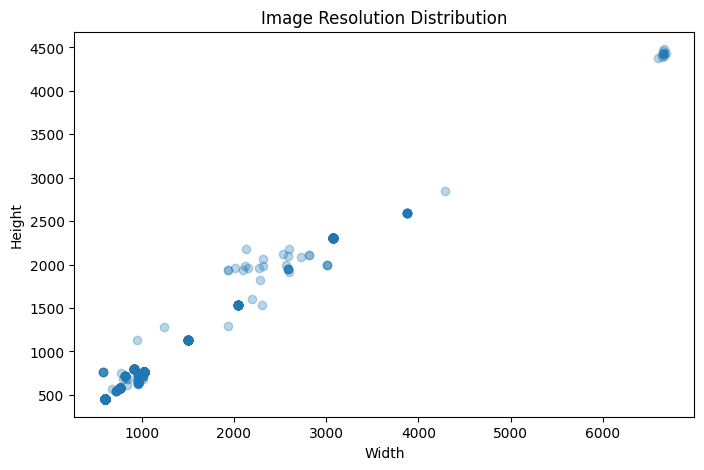

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(widths,heights,alpha=0.3)

plt.xlabel("Width")

plt.ylabel("Height")

plt.title("Image Resolution Distribution")

plt.show()

##  Class Distribution


In [ ]:

class_counts={}

train_folder=os.path.join(DATASET_PATH,"Train")

for cls in sorted(os.listdir(train_folder)):

    class_path=os.path.join(train_folder,cls)

    if os.path.isdir(class_path):

        class_counts[cls]=len([
            f for f in os.listdir(class_path)
            if f.lower().endswith(VALID_EXTENSIONS)
        ])

distribution=pd.DataFrame({
    "Class":class_counts.keys(),
    "Images":class_counts.values()
})

distribution

,Class,Images
0,actinic keratosis,114
1,basal cell carcinoma,376
2,dermatofibroma,95
3,melanoma,438
4,nevus,357
5,pigmented benign keratosis,462
6,seborrheic keratosis,77
7,squamous cell carcinoma,181
8,vascular lesion,139


#Bar chart

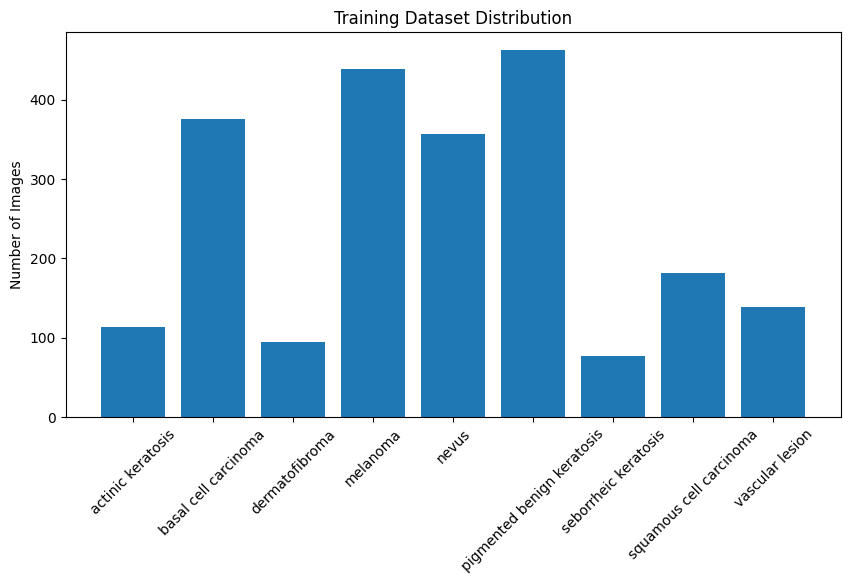

In [ ]:
plt.figure(figsize=(10,5))

plt.bar(distribution["Class"],distribution["Images"])

plt.xticks(rotation=45)

plt.ylabel("Number of Images")

plt.title("Training Dataset Distribution")

plt.show()

#Pie Chart

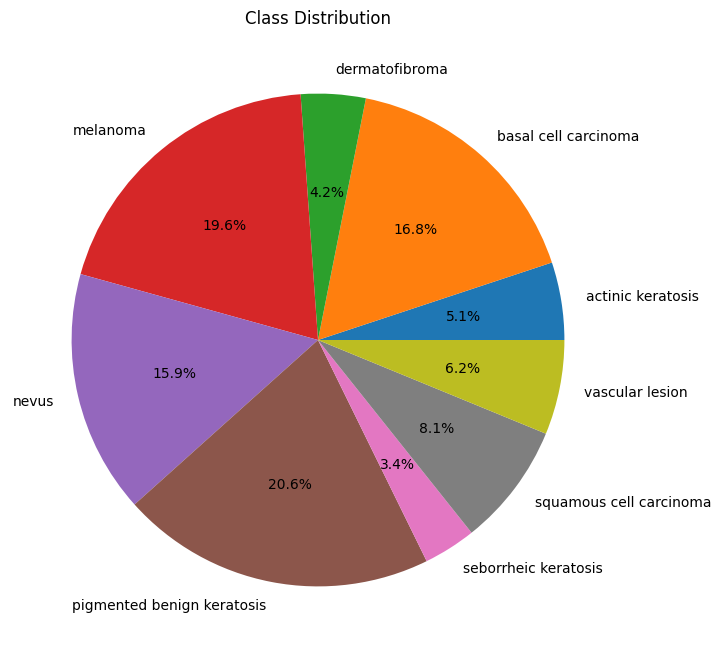

In [ ]:
plt.figure(figsize=(8,8))

plt.pie(
    distribution["Images"],
    labels=distribution["Class"],
    autopct="%1.1f%%"
)

plt.title("Class Distribution")

plt.show()

## Dataset Summary


In [ ]:

summary = {
    "Total Classes": len(class_counts),
    "Total Images": sum(class_counts.values()),
    "Smallest Class": min(class_counts, key=class_counts.get),
    "Largest Class": max(class_counts, key=class_counts.get),
    "Average Images Per Class": round(np.mean(list(class_counts.values())), 2)
}

summary_df = pd.DataFrame(summary.items(), columns=["Metric", "Value"])

summary_df

,Metric,Value
0,Total Classes,9
1,Total Images,2239
2,Smallest Class,seborrheic keratosis
3,Largest Class,pigmented benign keratosis
4,Average Images Per Class,248.78


#Save Sumery

In [ ]:
summary_df.to_csv("dataset_summary.csv", index=False)

print("Dataset summary saved as dataset_summary.csv")

Dataset summary saved as dataset_summary.csv


# Detect Duplicate Images

In [ ]:
import hashlib

hashes = {}
duplicates = []

for root, dirs, files in os.walk(DATASET_PATH):

    for file in files:

        if file.lower().endswith(VALID_EXTENSIONS):

            filepath = os.path.join(root, file)

            with open(filepath, "rb") as f:

                filehash = hashlib.md5(f.read()).hexdigest()

            if filehash in hashes:
                duplicates.append(filepath)

            else:
                hashes[filehash] = filepath

print("="*60)
print("Duplicate Images :", len(duplicates))
print("="*60)

Duplicate Images : 157


### Removing Duplicate Images


In [ ]:
for file in duplicates:
    os.remove(file)

print("Duplicate images removed.")

Duplicate images removed.


#Validation Checklist

✔ No corrupted images

✔ No duplicate images

✔ Dataset ready for splitting




#Train / Validation / Test Split

In [ ]:
print(os.listdir(DATASET_PATH))

['Test', 'Train']


# Create Output Directories

In [47]:
# OUTPUT_DATASET is now defined in the config cell (Wd-4F9RIRweT)

for split in ["train", "valid", "test"]:

    split_path = os.path.join(OUTPUT_DATASET, split)

    os.makedirs(split_path, exist_ok=True)

print("Folders Created Successfully")

Folders Created Successfully


#Split images

In [48]:
# shutil and sklearn.model_selection are now imported at the top

TRAIN_PATH = os.path.join(DATASET_PATH, "Train")

for class_name in sorted(os.listdir(TRAIN_PATH)):

    class_folder = os.path.join(TRAIN_PATH, class_name)

    if not os.path.isdir(class_folder):
        continue

    images = [
        os.path.join(class_folder, img)
        for img in os.listdir(class_folder)
        if img.lower().endswith(VALID_EXTENSIONS)
    ]

    train_imgs, temp_imgs = train_test_split(
        images,
        test_size=0.20,
        random_state=SEED # Use the global SEED
    )

    valid_imgs, test_imgs = train_test_split(
        temp_imgs,
        test_size=0.50,
        random_state=SEED # Use the global SEED
    )

    for split_name, split_imgs in zip(
        ["train", "valid", "test"],
        [train_imgs, valid_imgs, test_imgs]
    ):

        destination = os.path.join(
            OUTPUT_DATASET,
            split_name,
            class_name
        )

        os.makedirs(destination, exist_ok=True)

        for img in split_imgs:
            shutil.copy(img, destination)

print("Dataset Splitting Completed")

Dataset Splitting Completed


#Verify Split

In [ ]:
for split in ["train", "valid", "test"]:

    print("\n", split.upper())

    split_folder = os.path.join(OUTPUT_DATASET, split)

    for cls in sorted(os.listdir(split_folder)):

        cls_folder = os.path.join(split_folder, cls)

        print(
            cls,
            len(os.listdir(cls_folder))
        )


 TRAIN
actinic keratosis 91
basal cell carcinoma 300
dermatofibroma 76
melanoma 287
nevus 223
pigmented benign keratosis 369
seborrheic keratosis 61
squamous cell carcinoma 144
vascular lesion 111

 VALID
actinic keratosis 11
basal cell carcinoma 38
dermatofibroma 9
melanoma 36
nevus 28
pigmented benign keratosis 46
seborrheic keratosis 8
squamous cell carcinoma 18
vascular lesion 14

 TEST
actinic keratosis 12
basal cell carcinoma 38
dermatofibroma 10
melanoma 36
nevus 28
pigmented benign keratosis 47
seborrheic keratosis 8
squamous cell carcinoma 19
vascular lesion 14


#Validation Checklist

✔ Every class exists in Train

✔ Every class exists in Validation

✔ Every class exists in Test

✔ Images successfully copied

#Image Preprocessing & Data Augmentation

#import and Training Transform

In [49]:
# torchvision.transforms is now imported at the top

train_transform = transforms.Compose([

    transforms.Resize(IMAGE_SIZE),

    transforms.RandomHorizontalFlip(),

    transforms.RandomVerticalFlip(),

    transforms.RandomRotation(20),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

#Validate Transform

In [50]:
valid_transform = transforms.Compose([

    transforms.Resize(IMAGE_SIZE),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

#Test and Display Transform Pipeline

In [ ]:
test_transform = valid_transform
print(train_transform)

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.5)
    RandomRotation(degrees=[-20.0, 20.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [51]:
# ImageFolder is now imported from torchvision.datasets at the top

#Dataset path

In [ ]:
TRAIN_DIR = os.path.join(OUTPUT_DATASET, "train")

VALID_DIR = os.path.join(OUTPUT_DATASET, "valid")

TEST_DIR = os.path.join(OUTPUT_DATASET, "test")

print(TRAIN_DIR)
print(VALID_DIR)
print(TEST_DIR)

/content/processed_dataset/train
/content/processed_dataset/valid
/content/processed_dataset/test


#Create Dataset object

In [ ]:
train_dataset = ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform
)

valid_dataset = ImageFolder(
    root=VALID_DIR,
    transform=valid_transform
)

test_dataset = ImageFolder(
    root=TEST_DIR,
    transform=test_transform
)

#Display dataset information

In [ ]:
print("="*60)

print("Training Images :", len(train_dataset))

print("Validation Images :", len(valid_dataset))

print("Testing Images :", len(test_dataset))

print("="*60)

print(train_dataset.classes) #Display class names
print(train_dataset.class_to_idx) #Display label mapping

Training Images : 1662
Validation Images : 208
Testing Images : 212
['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']
{'actinic keratosis': 0, 'basal cell carcinoma': 1, 'dermatofibroma': 2, 'melanoma': 3, 'nevus': 4, 'pigmented benign keratosis': 5, 'seborrheic keratosis': 6, 'squamous cell carcinoma': 7, 'vascular lesion': 8}


#sumery

In [ ]:
print("="*60)

print("Dataset Successfully Loaded")

print("Classes :", len(train_dataset.classes))

print("="*60)

Dataset Successfully Loaded
Classes : 9


#Validation Checklist

✔ Dataset Loaded

✔ Labels Assigned

✔ Transform Applied

✔ Ready for DataLoade

#import Dataloader , Train , validate and Configuratioon

In [52]:
# torch.utils.data.DataLoader is now imported at the top


train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=NUM_WORKERS,

    pin_memory=True
)



valid_loader = DataLoader(

    valid_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=True
)

#Testing Loader & Display information

In [ ]:
test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=True
)


print("="*60)

print("Train Batches :", len(train_loader))

print("Validation Batches :", len(valid_loader))

print("Test Batches :", len(test_loader))

print("="*60)

Train Batches : 52
Validation Batches : 7
Test Batches : 7


#Validation Checklist

✔ DataLoader Created

✔ Batch Size Correct

✔ Shuffle Enabled

✔ GPU Optimized

#Load First batch and Display shapes and label values

In [ ]:
images, labels = next(iter(train_loader))

print("="*60)

print("Images Shape :", images.shape)

print("Labels Shape :", labels.shape)

print("="*60)

print(labels)

Images Shape : torch.Size([32, 3, 224, 224])
Labels Shape : torch.Size([32])
tensor([1, 7, 4, 5, 2, 1, 7, 7, 1, 1, 3, 5, 3, 3, 4, 1, 4, 1, 4, 4, 1, 5, 8, 5,
        1, 5, 1, 0, 6, 4, 0, 5])


#Visualize Batch

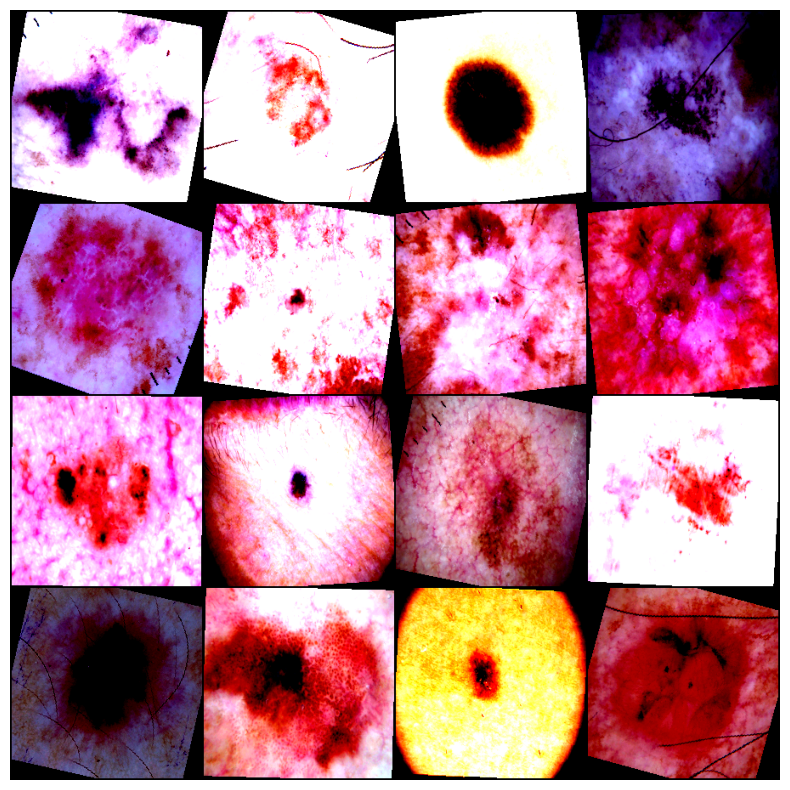

In [ ]:
import matplotlib.pyplot as plt
import torchvision

grid = torchvision.utils.make_grid(images[:16], nrow=4)

grid = grid.permute(1,2,0)

plt.figure(figsize=(10,10))

plt.imshow(grid)

plt.axis("off")

plt.show()

#Reverse Normalization

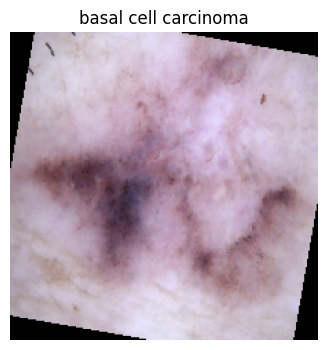

In [ ]:
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

sample = images[0] * std + mean
sample = sample.clamp(0,1)

plt.figure(figsize=(4,4))
plt.imshow(sample.permute(1,2,0))
plt.title(train_dataset.classes[labels[0]])
plt.axis("off")
plt.show()

#Final Validation

In [ ]:
print("="*60)

print("Dataset Ready for Model Training")

print("Image Size :", images.shape[2:])

print("Channels :", images.shape[1])

print("Batch Size :", images.shape[0])

print("="*60)

Dataset Ready for Model Training
Image Size : torch.Size([224, 224])
Channels : 3
Batch Size : 32


#Visualize Original vs Augmented Images

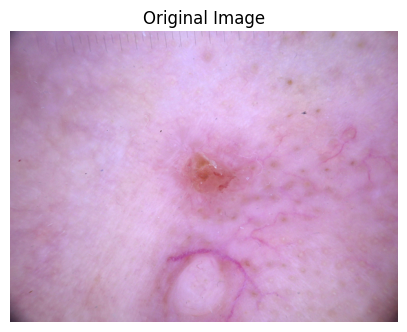

In [ ]:

from PIL import Image
import matplotlib.pyplot as plt
import random
import os

sample_class = random.choice(train_dataset.classes)

sample_folder = os.path.join(TRAIN_DIR, sample_class)

sample_image = random.choice(os.listdir(sample_folder))

image_path = os.path.join(sample_folder, sample_image)

original = Image.open(image_path).convert("RGB")

plt.figure(figsize=(5,5))
plt.imshow(original)
plt.title("Original Image")
plt.axis("off")
plt.show()

## Apply Data Augmentation


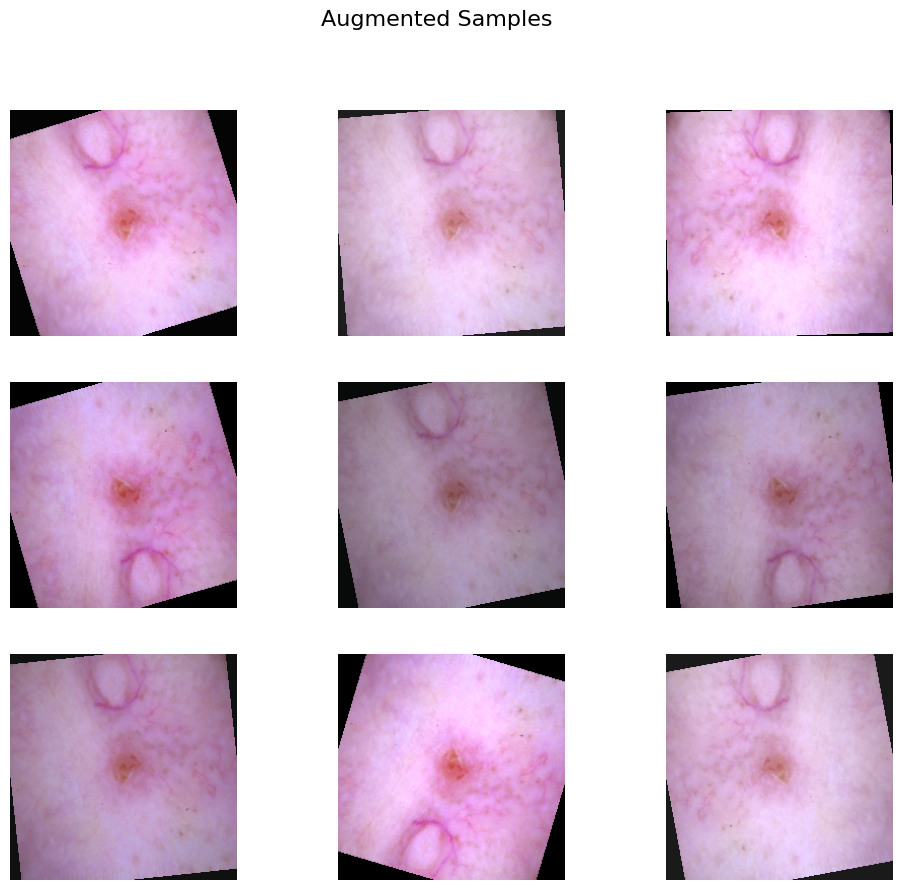

In [ ]:

plt.figure(figsize=(12,10))

for i in range(9):

    augmented = train_transform(original)

    augmented = augmented.permute(1,2,0)

    augmented = augmented.numpy()

    mean = np.array([0.485,0.456,0.406])
    std = np.array([0.229,0.224,0.225])

    augmented = std * augmented + mean

    augmented = np.clip(augmented,0,1)

    plt.subplot(3,3,i+1)

    plt.imshow(augmented)

    plt.axis("off")

plt.suptitle("Augmented Samples",fontsize=16)

plt.show()

#Validation Checklist

✔ Images remain realistic

✔ Lesion remains visible

✔ No excessive distortion

#Get one batch and  Verify Tensor Shapes

In [ ]:
images,labels = next(iter(train_loader))

print("="*50)

print("Images Shape :",images.shape)

print("Labels Shape :",labels.shape)

print("="*50)

Images Shape : torch.Size([32, 3, 224, 224])
Labels Shape : torch.Size([32])


#Display first 16 images

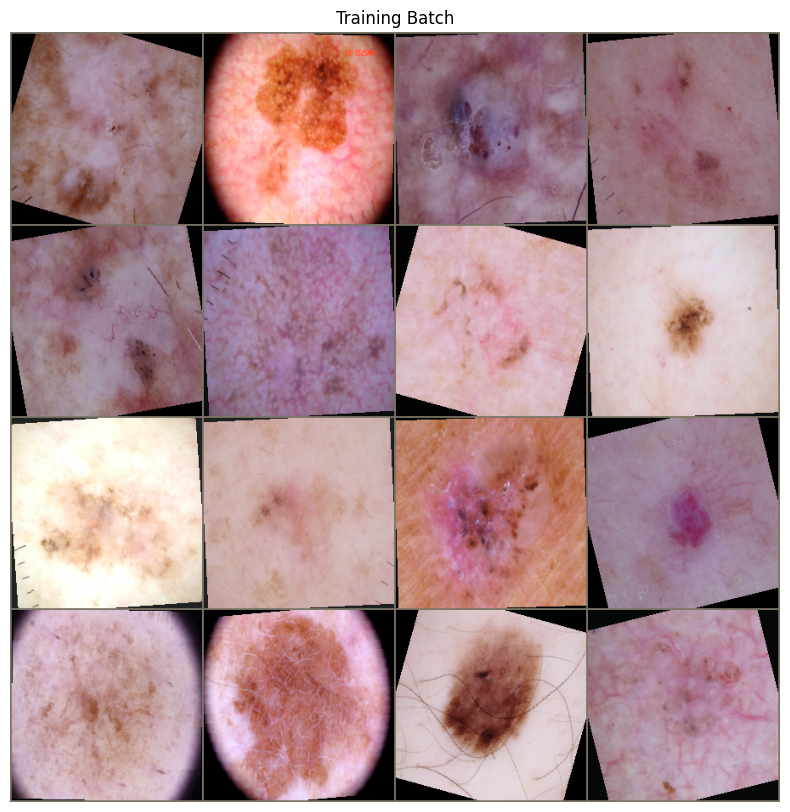

tensor([7, 3, 1, 1, 1, 3, 7, 5, 3, 1, 1, 8, 5, 5, 3, 1])


In [ ]:
import torchvision

grid = torchvision.utils.make_grid(images[:16],nrow=4)

grid = grid.permute(1,2,0)

mean=np.array([0.485,0.456,0.406])
std=np.array([0.229,0.224,0.225])

grid=grid.numpy()

grid=std*grid+mean

grid=np.clip(grid,0,1)

plt.figure(figsize=(10,10))

plt.imshow(grid)

plt.axis("off")

plt.title("Training Batch")

plt.show()

print(labels[:16])

#Validation Checklist

✔ Batch Size Correct

✔ Labels Correct

✔ Images Correctly Loaded

#Dataset Stats

#Number of Clasess and image per spliit

In [ ]:
print("Classes:",len(train_dataset.classes))

print("="*60)

print("Training :",len(train_dataset))

print("Validation :",len(valid_dataset))

print("Testing :",len(test_dataset))

print("="*60)

for class_name,count in class_counts.items():   #images per class

    print(f"{class_name:<15}{count}")

Classes: 9
Training : 1662
Validation : 208
Testing : 212
actinic keratosis114
basal cell carcinoma376
dermatofibroma 95
melanoma       438
nevus          357
pigmented benign keratosis462
seborrheic keratosis77
squamous cell carcinoma181
vascular lesion139


#Summery and Export Stats

In [ ]:
dataset_statistics=pd.DataFrame({

    "Class":list(class_counts.keys()),

    "Training Images":list(class_counts.values())

})

dataset_statistics

dataset_statistics.to_csv(

    "dataset_statistics.csv",

    index=False

)

print("Statistics Saved Successfully")

Statistics Saved Successfully


#Final Dataset Validation

In [ ]:
def validate_dataset():

    print("="*60)

    print("FINAL DATASET VALIDATION")

    print("="*60)

    print()

    print("Training Images :",len(train_dataset))

    print("Validation Images :",len(valid_dataset))

    print("Testing Images :",len(test_dataset))

    print()

    print("Classes :",len(train_dataset.classes))

    print()

    print("Batch Size :",BATCH_SIZE)

    print()

    print("Image Size :",IMAGE_SIZE)

    print()

    print("Transform Ready")

    print()

    print("DataLoader Ready")

    print()

    print("Dataset Ready for Training")

    print("="*60)

validate_dataset() #excute validate


FINAL DATASET VALIDATION

Training Images : 1662
Validation Images : 208
Testing Images : 212

Classes : 9

Batch Size : 32

Image Size : (224, 224)

Transform Ready

DataLoader Ready

Dataset Ready for Training


#Save Preposition

In [53]:
# json is now imported at the top

config={

    "image_size":IMAGE_SIZE,

    "batch_size":BATCH_SIZE,

    "num_classes":len(train_dataset.classes),

    "classes":train_dataset.classes,

    "mean":[0.485,0.456,0.406],

    "std":[0.229,0.224,0.225]

}

with open("preprocessing_config.json","w") as f:

    json.dump(config,f,indent=4)

print("Configuration Saved")

Configuration Saved


#Export clas and Data Stats

In [54]:
# os, pandas, kagglehub are imported at the top

# Ensure EXPORT_DIR exists
os.makedirs(EXPORT_DIR, exist_ok=True)

# dataset_config should be defined once, e.g., here or in the config cell
dataset_config = {
    "project": PROJECT_NAME,
    "dataset": "Skin Cancer ISIC"
}

# Use the class_counts and distribution generated after duplicate removal (from rvP6HsYMU67V)
distribution.to_csv(os.path.join(EXPORT_DIR, "class_distribution.csv"), index=False)
print("Class Distribution Saved to:", EXPORT_DIR)

Class Distribution Saved to: /content/exports


#Save Class Mapping

In [55]:

mapping = pd.DataFrame({
    "Class": train_dataset.classes,
    "Label": range(len(train_dataset.classes))
})

mapping

,Class,Label
0,actinic keratosis,0
1,basal cell carcinoma,1
2,dermatofibroma,2
3,melanoma,3
4,nevus,4
5,pigmented benign keratosis,5
6,seborrheic keratosis,6
7,squamous cell carcinoma,7
8,vascular lesion,8


#Save Csv and Class Names

In [34]:
mapping.to_csv(

    os.path.join(
        EXPORT_DIR,
        "label_mapping.csv"
    ),

    index=False
)

print("Label Mapping Saved")



Label Mapping Saved


In [35]:
import os

# Save classes to text file using the re-initialized train_dataset
with open(os.path.join(EXPORT_DIR, "classes.txt"), "w") as file:
    for cls in train_dataset.classes:
        file.write(cls + "\n")

print("Classes Saved")

Classes Saved


#Final Validation

In [38]:
def preprocessing_validation():

    print("=" * 70)
    print("Lifora AI")
    print("PREPROCESSING VALIDATION REPORT")
    print("=" * 70)

    print(f"Project              : {dataset_config['project']}")
    print(f"Dataset              : {dataset_config['dataset']}")
    print(f"Training Images      : {len(train_dataset)}")
    print(f"Validation Images    : {len(valid_dataset)}")
    print(f"Testing Images       : {len(test_dataset)}")
    print(f"Number of Classes    : {len(train_dataset.classes)}")
    print(f"Image Size           : {IMAGE_SIZE}")
    print(f"Batch Size           : {BATCH_SIZE}")
    print(f"Random Seed          : {SEED}")

    print("\nChecks")
    print("-" * 70)

    print("Dataset Loaded            ✓")
    print("Transforms Ready          ✓")
    print("DataLoader Ready          ✓")
    print("Configuration Saved       ✓")
    print("Class Mapping Saved       ✓")
    print("Dataset Statistics Saved  ✓")

    print("=" * 70)
    print("Notebook 02 Completed Successfully")
    print("=" * 70)



In [56]:


preprocessing_validation()

Lifora AI
PREPROCESSING VALIDATION REPORT
Project              : Lifora AI
Dataset              : Skin Cancer ISIC
Training Images      : 1787
Validation Images    : 224
Testing Images       : 228
Number of Classes    : 9
Image Size           : (224, 224)
Batch Size           : 32
Random Seed          : 42

Checks
----------------------------------------------------------------------
Dataset Loaded            ✓
Transforms Ready          ✓
DataLoader Ready          ✓
Configuration Saved       ✓
Class Mapping Saved       ✓
Dataset Statistics Saved  ✓
Notebook 02 Completed Successfully
